In previous lectures we introduced discrete random variables and their distributions. We now discuss the most important numerical characteristics of a random variable: its **expectation** and **variance**.

Roughly speaking, the expectation describes the center of a distribution, while the variance measures the spread of the values around that center.

# Expectation of a Discrete Random Variable

Let $\xi$ be a discrete random variable taking values

$$
X_\xi=\{x_1,x_2,\ldots\}.
$$

The **expectation** (or **mean**) of $\xi$ is defined by

$$
\mathbb E[\xi]
=
\sum_i x_i\,\mathbb P(\xi=x_i),
$$

provided that the series $\sum_i |x_i|\,\mathbb P(\xi=x_i)$ converges.

## Properties of Expectation

The expectation enjoys several important properties.

### Linearity

For any constants $a,b\in\mathbb R$,

$$
\mathbb E[a\xi+\eta b]
=
a\,\mathbb E[\xi]+b\,\mathbb E[\eta].
$$

A remarkable fact is that **independence is not required** for this property.

### Expectation of a Function

Let $\varphi:\mathbb R\to\mathbb R$ be a function. Then

$$
\mathbb E[\varphi(\xi)]
=
\sum_i
\varphi(x_i)\,
\mathbb P(\xi=x_i).
$$

This formula allows us to compute expectations of transformed random variables directly from the distribution of $\xi$.

### Monotonicity

If $\xi \le \eta$ almost surely, then $\mathbb E[\xi] \le \mathbb E[\eta]$.


### Absolute Value Inequality

For every random variable,

$$
\bigl|\mathbb E[\xi]\bigr|
\le
\mathbb E[|\xi|].
$$

This inequality is often useful when estimating expectations.

### Product of Independent Random Variables

If $\xi$ and $\eta$ are independent, then

$$
\mathbb E[\xi\eta]
=
\mathbb E[\xi]\,
\mathbb E[\eta].
$$

This property generally fails if the random variables are not independent.

## Simulations on Expectation

In this part of the seminar, we use simulations to understand expectation empirically. The goal is not only to compute formulas, but to see what these quantities mean when we generate data.

Throughout the notebook, we use the empirical mean

$$
\overline X_n=\frac{1}{n}\sum_{i=1}^n X_i
$$

as an approximation to the theoretical expectation $\mathbb E[X]$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

### Simulation 1: Expectation of a Fair Die

Let $\xi$ be the result of rolling a fair die. Then $\xi$ takes values $1,2,3,4,5,6$ with equal probabilities. Therefore,

$$
\mathbb E[\xi]=\frac{1+2+3+4+5+6}{6}=3.5.
$$

Notice that $3.5$ is not a possible outcome of a die roll. This is an important point: the expectation is not necessarily the most likely value, nor even a possible value. It is a long-run average.

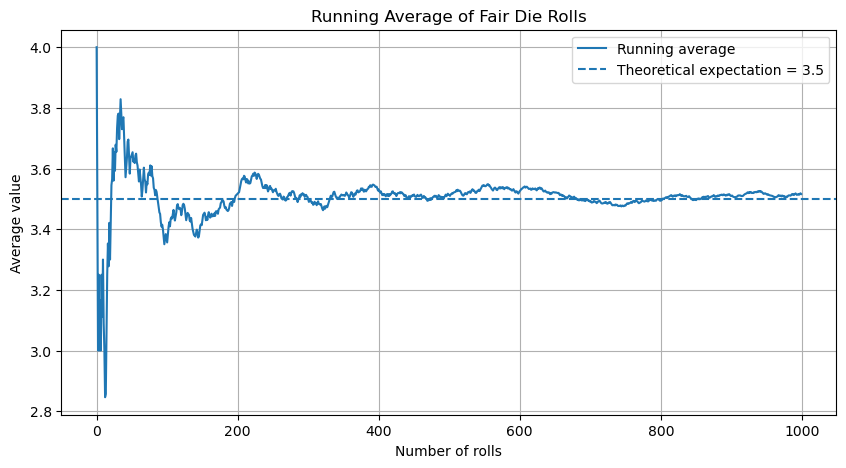

In [14]:
n = 1_000

rolls = np.random.randint(1, 7, size=n)
running_average = np.cumsum(rolls) / np.arange(1, n + 1)

plt.figure(figsize=(10, 5))
plt.plot(running_average, label="Running average")
plt.axhline(3.5, linestyle="--", label="Theoretical expectation = 3.5")
plt.xlabel("Number of rolls")
plt.ylabel("Average value")
plt.title("Running Average of Fair Die Rolls")
plt.legend()
plt.grid(True)
plt.show()

### Simulation 2: Rare Event Bernoulli Random Variable

Let $\xi\sim\operatorname{Ber}(0.05)$. We may interpret $\xi=1$ as a user clicking an advertisement and $\xi=0$ as not clicking it. Then

$$
\mathbb E[\xi]=0.05.
$$

Most observations are equal to $0$, but the long-run average still approaches $0.05$.

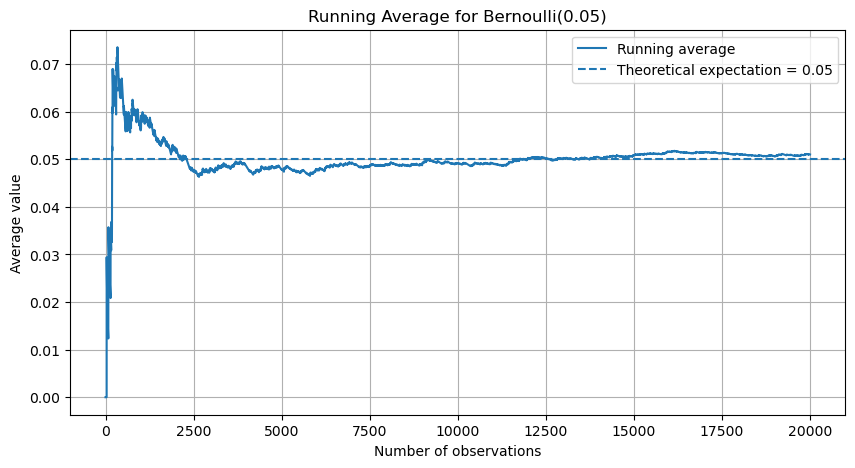

Empirical mean: 0.051
Theoretical mean: 0.05


In [15]:
n = 20_000
p = 0.05

x = np.random.binomial(1, p, size=n)
running_average = np.cumsum(x) / np.arange(1, n + 1)

plt.figure(figsize=(10, 5))
plt.plot(running_average, label="Running average")
plt.axhline(p, linestyle="--", label="Theoretical expectation = 0.05")
plt.xlabel("Number of observations")
plt.ylabel("Average value")
plt.title("Running Average for Bernoulli(0.05)")
plt.legend()
plt.grid(True)
plt.show()

print("Empirical mean:", np.mean(x))
print("Theoretical mean:", p)

# Variance

While the expectation tells us where a distribution is centered, it does not tell us how spread out the values are.

The **variance** of a random variable $\xi$ is defined by

$$
\operatorname{Var}(\xi)
=
\mathbb E\!\left[(\xi-\mathbb E[\xi])^2\right].
$$

The quantity

$$
\sigma_\xi
=
\sqrt{\operatorname{Var}(\xi)}
$$

is called the **standard deviation**.

## Alternative Formula for Variance

Expanding the square gives

$$
\operatorname{Var}(\xi)
=
\mathbb E[\xi^2]
-
\bigl(\mathbb E[\xi]\bigr)^2.
$$

This formula is often much easier to use in computations.

## Properties of Variance

1. $\operatorname{Var}(\xi)\ge 0$. Moreover, $\operatorname{Var}(\xi)=0 \iff \mathbb P(\xi=c)=1$, for some constant $c$.

2. For any constants $a,b\in\mathbb R$,

$$
\operatorname{Var}(a\xi+b)
=
a^2\operatorname{Var}(\xi).
$$
3. If $\xi$ and $\eta$ are independent, then 
$$\operatorname{Var}(\xi+\eta)=\operatorname{Var}(\xi)+\operatorname{Var}(\eta).$$

# Important Examples

The following expectations and variances are useful enough to remember.

<table style="width:100%; border-collapse: collapse; font-size: 16px;">
  <thead>
    <tr>
      <th style="border-bottom: 2px solid black; padding: 8px; text-align: left;">Distribution</th>
      <th style="border-bottom: 2px solid black; padding: 8px; text-align: center;">Expectation</th>
      <th style="border-bottom: 2px solid black; padding: 8px; text-align: center;">Variance</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;">$\operatorname{Ber}(p)$</td>
      <td style="padding: 8px; text-align: center;">$p$</td>
      <td style="padding: 8px; text-align: center;">$p(1-p)$</td>
    </tr>
    <tr>
      <td style="padding: 8px;">$\operatorname{Bin}(n,p)$</td>
      <td style="padding: 8px; text-align: center;">$np$</td>
      <td style="padding: 8px; text-align: center;">$np(1-p)$</td>
    </tr>
    <tr>
      <td style="padding: 8px;">$\operatorname{Geom}(p)$</td>
      <td style="padding: 8px; text-align: center;">$\frac{1}{p}$</td>
      <td style="padding: 8px; text-align: center;">$\frac{1-p}{p^2}$</td>
    </tr>
    <tr>
      <td style="padding: 8px;">$\operatorname{Pois}(\lambda)$</td>
      <td style="padding: 8px; text-align: center;">$\lambda$</td>
      <td style="padding: 8px; text-align: center;">$\lambda$</td>
    </tr>
    <tr>
      <td style="padding: 8px;">$U(\{1,\ldots,n\})$</td>
      <td style="padding: 8px; text-align: center;">$\frac{n+1}{2}$</td>
      <td style="padding: 8px; text-align: center;">$\frac{n^2-1}{12}$</td>
    </tr>
  </tbody>
</table>

## Comparing Different Distributions

The following figure compares a Binomial, Poisson, and Geometric distribution.

For each distribution:

- the **red dashed line** shows the expectation $\mu$;
- the **blue dotted lines** show $\mu\pm\sigma$;
- the **green dotted lines** show $\mu\pm2\sigma$.

Although expectation and variance provide useful summaries of a distribution, they do not completely describe its shape. Notice how the three distributions differ in symmetry, spread, and skewness despite having well-defined means and variances.

Throughout the notebook, we use the empirical variance

$$
s_n^2
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(X_i-\overline X_n\right)^2
$$

as an approximation to the theoretical variance $\operatorname{Var}(X)$.

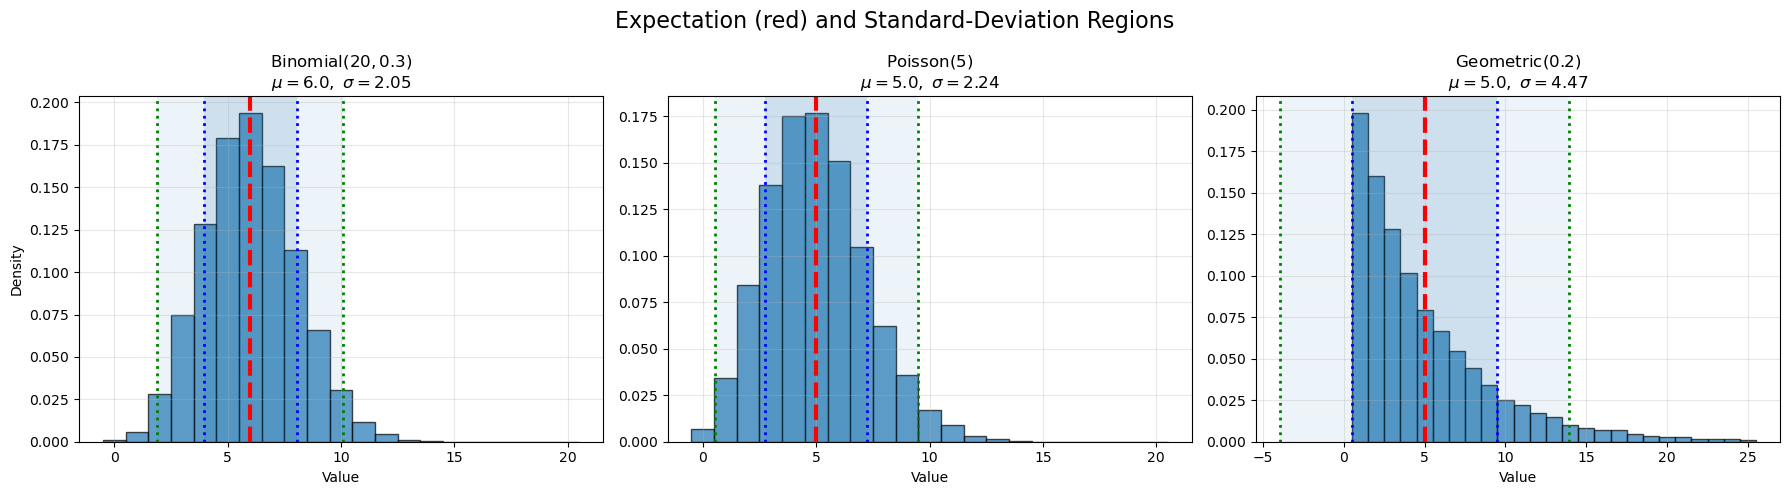

In [22]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_sim = 20_000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =====================================================
# Binomial
# =====================================================

n = 20
p = 0.3

x = np.random.binomial(n, p, size=n_sim)

mu = n * p
sigma = np.sqrt(n * p * (1 - p))

ax = axes[0]

ax.hist(
    x,
    bins=np.arange(-0.5, n + 1.5, 1),
    density=True,
    edgecolor="black",
    alpha=0.7
)

ax.axvline(mu, color="red", linestyle="--", linewidth=3)

ax.axvline(mu - sigma, color="blue", linestyle=":", linewidth=2)
ax.axvline(mu + sigma, color="blue", linestyle=":", linewidth=2)

ax.axvline(mu - 2*sigma, color="green", linestyle=":", linewidth=2)
ax.axvline(mu + 2*sigma, color="green", linestyle=":", linewidth=2)

ax.axvspan(mu-sigma, mu+sigma, alpha=0.15)
ax.axvspan(mu-2*sigma, mu+2*sigma, alpha=0.08)

ax.set_title(
    rf"Binomial$(20,0.3)$" "\n"
    rf"$\mu={mu:.1f},\ \sigma={sigma:.2f}$"
)

ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)

# =====================================================
# Poisson
# =====================================================

lam = 5

x = np.random.poisson(lam, size=n_sim)

mu = lam
sigma = np.sqrt(lam)

ax = axes[1]

ax.hist(
    x,
    bins=np.arange(-0.5, np.max(x)+1.5, 1),
    density=True,
    edgecolor="black",
    alpha=0.7
)

ax.axvline(mu, color="red", linestyle="--", linewidth=3)

ax.axvline(mu - sigma, color="blue", linestyle=":", linewidth=2)
ax.axvline(mu + sigma, color="blue", linestyle=":", linewidth=2)

ax.axvline(mu - 2*sigma, color="green", linestyle=":", linewidth=2)
ax.axvline(mu + 2*sigma, color="green", linestyle=":", linewidth=2)

ax.axvspan(mu-sigma, mu+sigma, alpha=0.15)
ax.axvspan(mu-2*sigma, mu+2*sigma, alpha=0.08)

ax.set_title(
    rf"Poisson$(5)$" "\n"
    rf"$\mu={mu:.1f},\ \sigma={sigma:.2f}$"
)

ax.set_xlabel("Value")
ax.grid(alpha=0.3)

# =====================================================
# Geometric
# =====================================================

p = 0.2

x = np.random.geometric(p, size=n_sim)

mu = 1/p
sigma = np.sqrt((1-p)/p**2)

ax = axes[2]

ax.hist(
    x,
    bins=np.arange(0.5, 26.5, 1),
    density=True,
    edgecolor="black",
    alpha=0.7
)

ax.axvline(mu, color="red", linestyle="--", linewidth=3)

ax.axvline(mu - sigma, color="blue", linestyle=":", linewidth=2)
ax.axvline(mu + sigma, color="blue", linestyle=":", linewidth=2)

ax.axvline(mu - 2*sigma, color="green", linestyle=":", linewidth=2)
ax.axvline(mu + 2*sigma, color="green", linestyle=":", linewidth=2)

ax.axvspan(mu-sigma, mu+sigma, alpha=0.15)
ax.axvspan(mu-2*sigma, mu+2*sigma, alpha=0.08)

ax.set_title(
    rf"Geometric$(0.2)$" "\n"
    rf"$\mu={mu:.1f},\ \sigma={sigma:.2f}$"
)

ax.set_xlabel("Value")
ax.grid(alpha=0.3)

plt.suptitle(
    "Expectation (red) and Standard-Deviation Regions",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Example: Sample Mean Becomes Less Variable

Let $X_1,\ldots,X_n$ be independent observations with expectation $\mu$ and variance $\sigma^2$. The sample mean is

$$
\overline X_n=\frac{1}{n}\sum_{i=1}^n X_i.
$$

Its variance is

$$
\operatorname{Var}(\overline X_n)=\frac{\sigma^2}{n}.
$$

Thus, as $n$ grows, the sample mean becomes more stable.

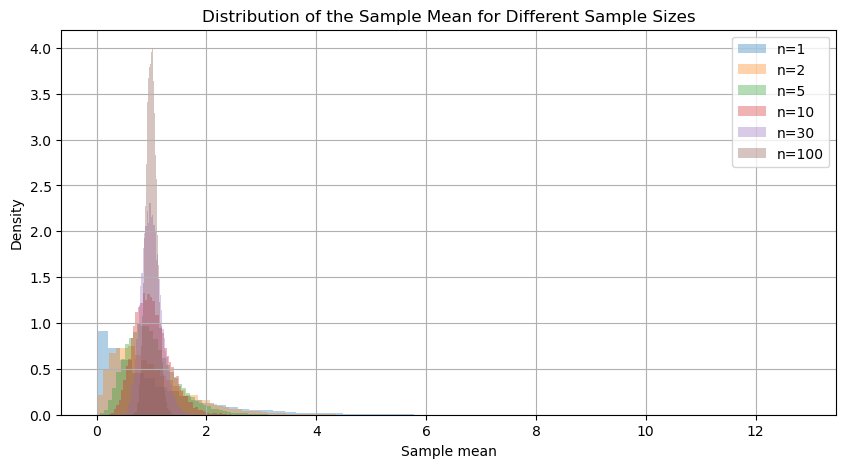

In [28]:
n_sim = 20_000
sample_sizes = [1, 2, 5, 10, 30, 100]

plt.figure(figsize=(10, 5))

for n in sample_sizes:
    samples = np.random.exponential(scale=1, size=(n_sim, n))
    sample_means = samples.mean(axis=1)
    plt.hist(sample_means, bins=60, density=True, alpha=0.35, label=f"n={n}")

plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.title("Distribution of the Sample Mean for Different Sample Sizes")
plt.legend()
plt.grid(True)
plt.show()

## Example: Apples and Oranges

A basket contains $4$ apples and $6$ oranges. We randomly choose $3$ fruits without replacement. Let $\xi$ be the number of apples among the selected fruits. Let's compute the expectation and variance of $\xi$.

Then $\xi$ can take the values $0,1,2,3$. Since we are sampling without replacement, $\xi$ has a hypergeometric distribution:

$$
\xi\sim\operatorname{Hypergeom}(N=10,K=4,n=3),
$$

where $N=10$ is the total number of fruits, $K=4$ is the number of apples, and $n=3$ is the number of selected fruits.

In the simulation below, we repeat the experiment many times and compare the empirical distribution with the theoretical one.

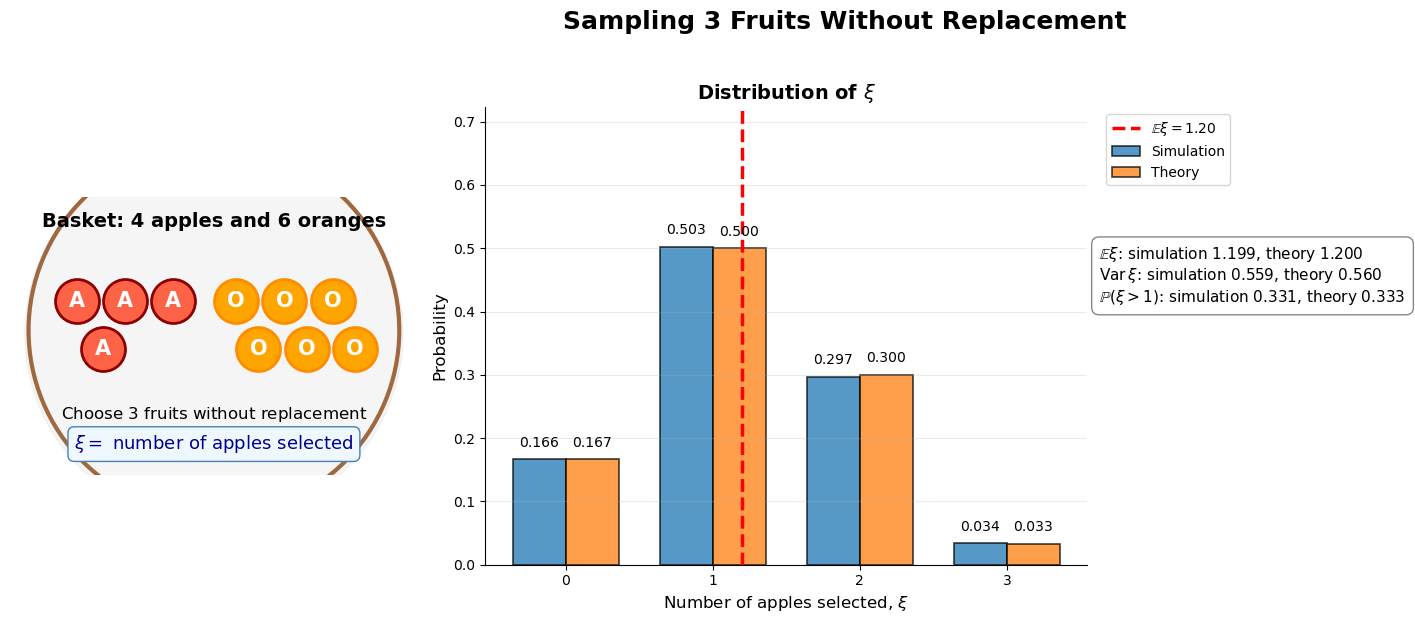

Theoretical probabilities:
P(xi = 0) = 0.1667
P(xi = 1) = 0.5000
P(xi = 2) = 0.3000
P(xi = 3) = 0.0333

Empirical mean        = 1.1985
Theoretical mean      = 1.2000

Empirical variance    = 0.5591
Theoretical variance  = 0.5600

Empirical P(xi > 1)   = 0.3311
Theoretical P(xi > 1) = 0.3333


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

np.random.seed(42)

# =====================================================
# Parameters
# =====================================================

n_sim = 100_000

N = 10          # total number of fruits
K = 4           # number of apples
M = 6           # number of oranges
n = 3           # number of selected fruits

# Basket: 1 = apple, 0 = orange
basket = np.array([1] * K + [0] * M)

# =====================================================
# Simulation
# =====================================================

simulated_xi = np.array([
    np.sum(np.random.choice(basket, size=n, replace=False))
    for _ in range(n_sim)
])

k_values = np.arange(0, n + 1)

empirical_probs = np.array([
    np.mean(simulated_xi == k)
    for k in k_values
])

theoretical_probs = np.array([
    comb(K, k) * comb(M, n - k) / comb(N, n)
    for k in k_values
])

# =====================================================
# Theoretical values
# =====================================================

mu = n * K / N

var = (
    n
    * (K / N)
    * (1 - K / N)
    * (N - n)
    / (N - 1)
)

# =====================================================
# Empirical values
# =====================================================

empirical_mean = np.mean(simulated_xi)
empirical_var = np.var(simulated_xi)

empirical_prob_gt_1 = np.mean(simulated_xi > 1)
theoretical_prob_gt_1 = np.sum(theoretical_probs[k_values > 1])

# =====================================================
# Plot
# =====================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 6),
    gridspec_kw={"width_ratios": [1.05, 1.55]}
)

fig.suptitle(
    r"Sampling 3 Fruits Without Replacement",
    fontsize=18,
    weight="bold",
    y=1.03
)

# =====================================================
# Left panel: basket drawing
# =====================================================

ax = axes[0]

apple_positions = [
    (0.9, 1.25), (1.55, 1.25), (2.2, 1.25), (1.25, 0.6)
]

orange_positions = [
    (3.05, 1.25), (3.7, 1.25), (4.35, 1.25),
    (3.35, 0.6), (4.0, 0.6), (4.65, 0.6)
]

# Basket shadow
shadow = plt.Circle(
    (2.75, 0.8),
    2.55,
    color="gray",
    alpha=0.08,
    zorder=0
)
ax.add_patch(shadow)

# Basket outline
basket_outline = plt.Circle(
    (2.75, 0.85),
    2.50,
    fill=False,
    linewidth=3,
    color="saddlebrown",
    alpha=0.8,
    zorder=1
)
ax.add_patch(basket_outline)

# Apples
for x_pos, y_pos in apple_positions:
    ax.scatter(
        x_pos, y_pos,
        s=1000,
        color="tomato",
        edgecolor="darkred",
        linewidth=2,
        zorder=3
    )
    ax.text(
        x_pos, y_pos,
        "A",
        color="white",
        fontsize=15,
        ha="center",
        va="center",
        weight="bold",
        zorder=4
    )

# Oranges
for x_pos, y_pos in orange_positions:
    ax.scatter(
        x_pos, y_pos,
        s=1000,
        color="orange",
        edgecolor="darkorange",
        linewidth=2,
        zorder=3
    )
    ax.text(
        x_pos, y_pos,
        "O",
        color="white",
        fontsize=15,
        ha="center",
        va="center",
        weight="bold",
        zorder=4
    )

ax.text(
    2.75, 2.25,
    "Basket: 4 apples and 6 oranges",
    ha="center",
    fontsize=14,
    weight="bold"
)

ax.text(
    2.75, -0.35,
    r"Choose $3$ fruits without replacement",
    ha="center",
    fontsize=12
)

ax.text(
    2.75, -0.75,
    r"$\xi =$ number of apples selected",
    ha="center",
    fontsize=13,
    color="darkblue",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="aliceblue",
        edgecolor="steelblue"
    )
)

ax.set_xlim(0, 5.5)
ax.set_ylim(-1.1, 2.65)
ax.set_aspect("equal")
ax.axis("off")

# =====================================================
# Right panel: empirical vs theoretical distribution
# =====================================================

ax = axes[1]

width = 0.36

bars_emp = ax.bar(
    k_values - width / 2,
    empirical_probs,
    width=width,
    label="Simulation",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.75
)

bars_th = ax.bar(
    k_values + width / 2,
    theoretical_probs,
    width=width,
    label="Theory",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.75
)

# Labels above bars
for bar in bars_emp:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar in bars_th:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Expectation line
ax.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label=fr"$\mathbb{{E}}\xi={mu:.2f}$"
)

ax.set_xticks(k_values)
ax.set_xlabel(r"Number of apples selected, $\xi$", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title(
    r"Distribution of $\xi$",
    fontsize=14,
    weight="bold"
)

ax.set_ylim(
    0,
    max(max(empirical_probs), max(theoretical_probs)) + 0.22
)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=True
)

# Summary box outside the plot
summary_text = (
    rf"$\mathbb{{E}}\xi$: simulation {empirical_mean:.3f}, theory {mu:.3f}" "\n"
    rf"$\operatorname{{Var}}\xi$: simulation {empirical_var:.3f}, theory {var:.3f}" "\n"
    rf"$\mathbb{{P}}(\xi>1)$: simulation {empirical_prob_gt_1:.3f}, theory {theoretical_prob_gt_1:.3f}"
)

ax.text(
    1.02,
    0.70,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

# =====================================================
# Numerical output
# =====================================================

print("Theoretical probabilities:")
for k, prob in zip(k_values, theoretical_probs):
    print(f"P(xi = {k}) = {prob:.4f}")

print()
print(f"Empirical mean        = {empirical_mean:.4f}")
print(f"Theoretical mean      = {mu:.4f}")

print()
print(f"Empirical variance    = {empirical_var:.4f}")
print(f"Theoretical variance  = {var:.4f}")

print()
print(f"Empirical P(xi > 1)   = {empirical_prob_gt_1:.4f}")
print(f"Theoretical P(xi > 1) = {theoretical_prob_gt_1:.4f}")

## Example: The Hat-Check Problem

A group of $n$ students throw their hats at graduation. After that, each student randomly picks one hat from the floor. Let $\xi$ be the number of students who get their own hat back.

In the simulation below, we randomly permute the hats many times and compare the empirical mean and variance with the theoretical values.

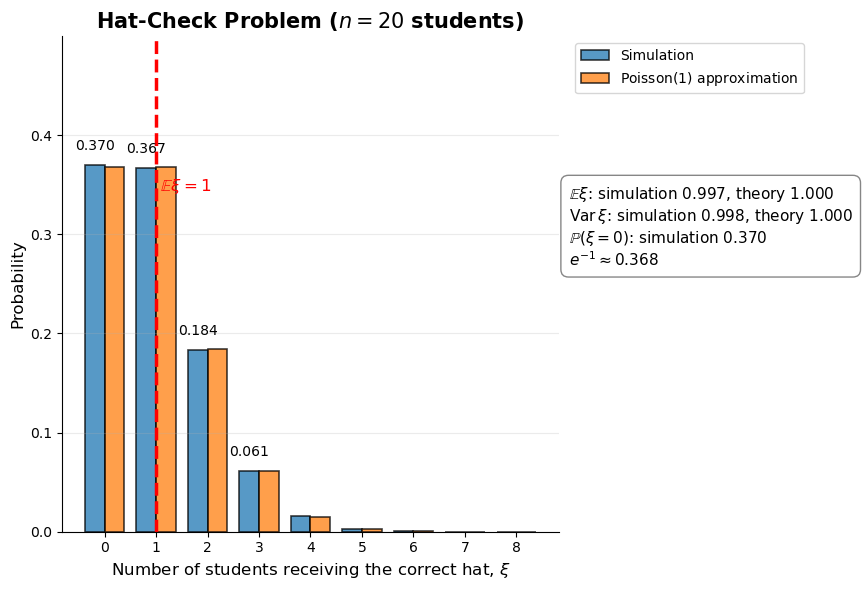

Number of students      = 20

Empirical mean          = 0.9968
Theoretical mean        = 1.0000

Empirical variance      = 0.9976
Theoretical variance    = 1.0000

Empirical P(xi = 0)     = 0.3695
Poisson approximation   = 0.3679


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

np.random.seed(42)

# =====================================================
# Parameters
# =====================================================

n_students = 20
n_sim = 100_000

students = np.arange(n_students)

# =====================================================
# Simulation
# =====================================================

fixed_points = []

for _ in range(n_sim):
    hats = np.random.permutation(n_students)
    fixed_points.append(np.sum(hats == students))

fixed_points = np.array(fixed_points)

# =====================================================
# Empirical and theoretical values
# =====================================================

empirical_mean = np.mean(fixed_points)
empirical_var = np.var(fixed_points)

theoretical_mean = 1
theoretical_var = 1

# =====================================================
# Distribution
# =====================================================

max_k = np.max(fixed_points)
k_values = np.arange(0, max_k + 1)

empirical_probs = np.array([
    np.mean(fixed_points == k)
    for k in k_values
])

poisson_probs = np.array([
    np.exp(-1) / factorial(k)
    for k in k_values
])

# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(figsize=(11, 6))

width = 0.38

bars_emp = ax.bar(
    k_values - width / 2,
    empirical_probs,
    width=width,
    label="Simulation",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.75
)

bars_pois = ax.bar(
    k_values + width / 2,
    poisson_probs,
    width=width,
    label=r"Poisson$(1)$ approximation",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.75
)

# Labels only above simulation bars to avoid overlap
for bar in bars_emp:
    height = bar.get_height()
    if height > 0.02:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.012,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

# Expected value line
ax.axvline(
    theoretical_mean,
    color="red",
    linestyle="--",
    linewidth=2.5
)

ax.text(
    theoretical_mean + 0.08,
    0.93 * max(empirical_probs),
    r"$\mathbb{E}\xi=1$",
    color="red",
    fontsize=12,
    weight="bold"
)

# Axes and title
ax.set_xticks(k_values)

ax.set_xlabel(
    r"Number of students receiving the correct hat, $\xi$",
    fontsize=12
)

ax.set_ylabel(
    "Probability",
    fontsize=12
)

ax.set_title(
    rf"Hat-Check Problem ($n={n_students}$ students)",
    fontsize=15,
    weight="bold"
)

ax.set_ylim(0, max(empirical_probs) + 0.13)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=True
)

# Summary box outside the plot
summary_text = (
    rf"$\mathbb{{E}}\xi$: simulation {empirical_mean:.3f}, theory {theoretical_mean:.3f}" "\n"
    rf"$\operatorname{{Var}}\xi$: simulation {empirical_var:.3f}, theory {theoretical_var:.3f}" "\n"
    rf"$\mathbb{{P}}(\xi=0)$: simulation {np.mean(fixed_points == 0):.3f}" "\n"
    rf"$e^{{-1}} \approx {np.exp(-1):.3f}$"
)

ax.text(
    1.02,
    0.70,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

# =====================================================
# Numerical summary
# =====================================================

print(f"Number of students      = {n_students}")
print()
print(f"Empirical mean          = {empirical_mean:.4f}")
print(f"Theoretical mean        = {theoretical_mean:.4f}")
print()
print(f"Empirical variance      = {empirical_var:.4f}")
print(f"Theoretical variance    = {theoretical_var:.4f}")
print()
print(f"Empirical P(xi = 0)     = {np.mean(fixed_points == 0):.4f}")
print(f"Poisson approximation   = {np.exp(-1):.4f}")

## Example: A Casino Game with Positive Expectation

Consider the following game. In one round, a player wins $\$10$ with probability $0.1$ and loses $\$1$ with probability $0.9$. Let $X$ be the profit from one round.

Then

$$
X=
\begin{cases}
10, & \text{with probability }0.1,\\
-1, & \text{with probability }0.9.
\end{cases}
$$

The expected profit is

$$
\mathbb E[X]
=
10\cdot 0.1+(-1)\cdot 0.9
=
0.1.
$$

So the game has positive expectation. However, this does not mean that a player is guaranteed to win. In the simulation below, we see that even a favorable game can produce losing streaks and negative outcomes over short periods.

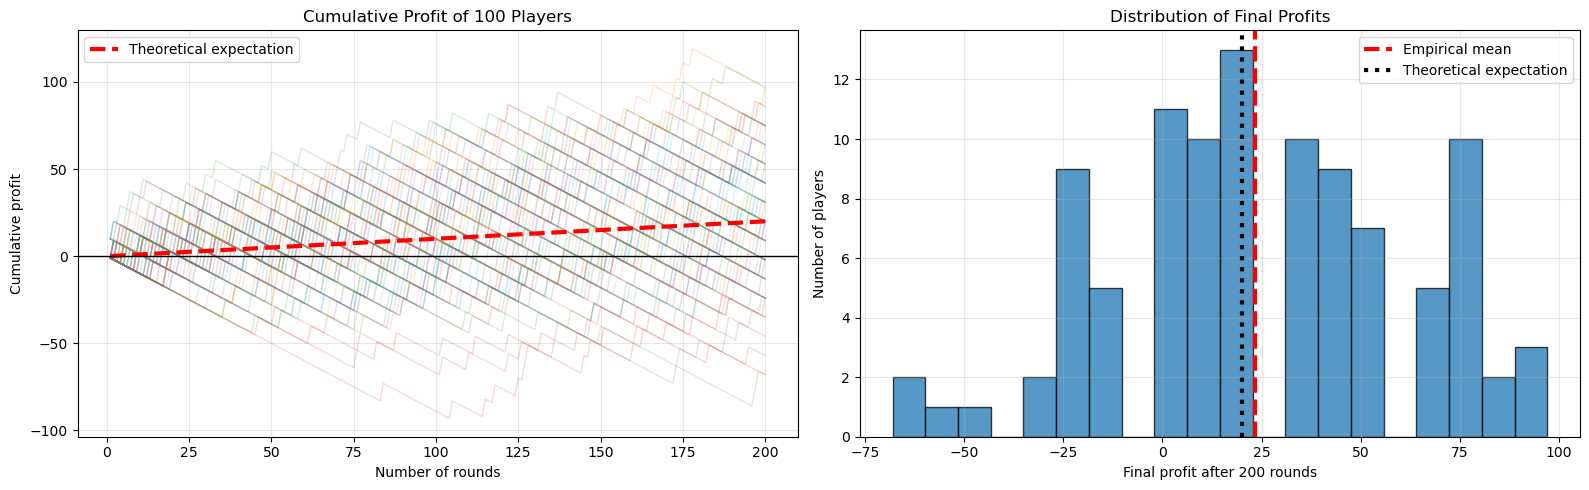

Expected profit per round      = 0.10
Expected profit after 200 rounds = 20.00

Empirical mean final profit    = 23.30
Empirical variance             = 1397.55

Fraction of players who lost money = 0.310


In [38]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# =====================================================
# Parameters
# =====================================================

n_rounds = 200
n_players = 100

win_prob = 0.1
win_amount = 10
loss_amount = -1

# =====================================================
# Simulation
# =====================================================

profits = np.random.choice(
    [win_amount, loss_amount],
    size=(n_players, n_rounds),
    p=[win_prob, 1 - win_prob]
)

cumulative_profits = np.cumsum(profits, axis=1)

expected_profit_per_round = win_amount * win_prob + loss_amount * (1 - win_prob)
expected_path = expected_profit_per_round * np.arange(1, n_rounds + 1)

final_profits = cumulative_profits[:, -1]

# =====================================================
# Plot
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -----------------------------------------------------
# Left plot: cumulative profit paths
# -----------------------------------------------------

ax = axes[0]

for i in range(n_players):
    ax.plot(
        np.arange(1, n_rounds + 1),
        cumulative_profits[i],
        alpha=0.18,
        linewidth=1
    )

ax.plot(
    np.arange(1, n_rounds + 1),
    expected_path,
    color="red",
    linewidth=3,
    linestyle="--",
    label=r"Theoretical expectation"
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Number of rounds")
ax.set_ylabel("Cumulative profit")
ax.set_title("Cumulative Profit of 100 Players")
ax.legend()
ax.grid(True, alpha=0.3)

# -----------------------------------------------------
# Right plot: final profits
# -----------------------------------------------------

ax = axes[1]

ax.hist(
    final_profits,
    bins=20,
    edgecolor="black",
    alpha=0.75
)

ax.axvline(
    np.mean(final_profits),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Empirical mean"
)

ax.axvline(
    expected_path[-1],
    color="black",
    linestyle=":",
    linewidth=3,
    label="Theoretical expectation"
)

ax.set_xlabel("Final profit after 200 rounds")
ax.set_ylabel("Number of players")
ax.set_title("Distribution of Final Profits")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# Numerical summary
# =====================================================

print(f"Expected profit per round      = {expected_profit_per_round:.2f}")
print(f"Expected profit after {n_rounds} rounds = {expected_path[-1]:.2f}")
print()
print(f"Empirical mean final profit    = {np.mean(final_profits):.2f}")
print(f"Empirical variance             = {np.var(final_profits):.2f}")
print()
print(f"Fraction of players who lost money = {np.mean(final_profits < 0):.3f}")

## Why Do We Care About Expectation and Variance?

At first glance, expectation and variance may seem like purely mathematical quantities. However, they appear in almost every area of statistics, data science, machine learning, finance, engineering, and scientific research.

The expectation describes what we should expect **on average** if an experiment is repeated many times, while the variance measures how much uncertainty or variability is present around that average.

In practice, good decisions often require understanding **both** quantities.